# Analysis for odd responses sqisign

In [22]:
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import math

In [2]:
p = 62

# Use the newest merged file for this p.
files = sorted(Path('.').glob(f'data/{p}-birandom-merged-*.csv.zip'))
if not files:
    raise FileNotFoundError(f'No merged CSV found for p={p}')
data_file = files[-1]
data_file

PosixPath('data/62-birandom-merged-20260714-084637.csv.zip')

In [3]:
columns = (
    ['I1', 'I2', 'I3', 'I4']
    + ['OL2', 'OL3', 'OL4']
    + ['OR2', 'OR3', 'OR4']
    + [f'inner{i}{j}' for i in range(1, 5) for j in range(1, 5)]
)

df = pd.read_csv(data_file, compression='zip', comment='#', header=None, names=columns)
df

,I1,I2,I3,I4,OL2,OL3,OL4,OR2,OR3,OR4,...,inner23,inner24,inner31,inner32,inner33,inner34,inner41,inner42,inner43,inner44
0,0.199057,0.373286,1.125247,1.166691,0.041085,1.155270,1.432343,0.153889,0.627164,0.680539,...,1,1,0,1,1,1,0,1,1,0
1,0.357934,0.502966,0.558076,1.063522,0.263841,0.273651,0.882299,0.230327,0.426679,0.640375,...,0,1,1,0,1,1,0,1,1,0
2,0.215919,0.410024,0.603909,1.335379,0.382591,0.438924,0.549756,0.264093,0.399542,0.667413,...,0,0,1,0,0,1,0,0,1,0
3,0.186652,0.299044,1.033956,1.202712,0.228714,0.357403,0.812369,0.030545,0.301301,6.885653,...,0,1,0,0,1,1,1,1,1,0
4,0.548765,0.557894,0.654248,0.680699,0.280264,0.462858,0.602370,0.173849,0.440133,0.902464,...,0,1,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389595,0.303508,0.488673,0.721278,0.893016,0.063247,0.766835,1.331061,0.108911,0.222514,2.655366,...,1,0,1,1,1,1,0,0,1,1
1389596,0.234448,0.337540,0.387869,2.526348,0.255071,0.522148,0.569731,0.116665,0.500064,1.186384,...,0,1,0,0,0,1,1,1,1,0
1389597,0.297053,0.469958,0.759035,0.904049,0.227549,0.309063,1.016116,0.170942,0.531672,0.744135,...,0,1,1,0,0,1,0,1,1,0
1389598,0.495633,0.512171,0.517708,0.730855,0.274642,0.553622,0.565361,0.060011,1.024492,1.025603,...,0,0,0,0,0,1,0,0,1,1


In [4]:
total_record = len(df)
total_record

1389600

Lets see if it ever happens that all 3 minima and their combinations are all even

In [5]:
print((df['inner11']*df['inner22']*df['inner12']*df['inner23']*df['inner13']*df['inner33']).sum()/total_record)

0.0


In [6]:
print((df['inner11']*df['inner22']*df['inner12']*df['inner23']*df['inner13']).sum()/total_record)

0.01916090961427749


In [7]:
print((df['inner11']*df['inner22']*df['inner12']*df['inner23']*df['inner33']).sum()/total_record)

0.019136442141623487


In [8]:
print((df['inner11']*df['inner22']*df['inner33']).sum()/total_record)

0.13354274611398964


In [9]:
print((df['inner11']*df['inner22']).sum()/total_record)

0.26681850892343123


In [10]:
df[['I1', 'I2', 'I3', 'I4']].corr()

,I1,I2,I3,I4
I1,1.000000,0.060854,-0.485474,-0.298137
I2,0.060854,1.000000,-0.005128,-0.267849
I3,-0.485474,-0.005128,1.000000,0.022982
I4,-0.298137,-0.267849,0.022982,1.000000


In [11]:
df[['inner11', 'inner12', 'inner13', 'inner14',
   'inner21', 'inner22', 'inner23', 'inner24',
   'inner31', 'inner32', 'inner33', 'inner34',
   'inner41', 'inner42', 'inner43', 'inner44']].corr()

,inner11,inner12,inner13,inner14,inner21,inner22,inner23,inner24,inner31,inner32,inner33,inner34,inner41,inner42,inner43,inner44
inner11,1.000000,-0.068884,-0.072063,-0.070617,-0.068884,-0.071568,0.003984,0.004653,-0.072063,0.003984,-0.070739,0.004745,-0.070617,0.004653,0.004745,-0.070664
inner12,-0.068884,1.000000,-0.071216,-0.072525,1.000000,-0.069224,-0.071178,-0.070720,-0.071216,-0.071178,0.004204,0.022937,-0.072525,-0.070720,0.022937,0.005371
inner13,-0.072063,-0.071216,1.000000,-0.072602,-0.071216,0.005267,-0.071263,0.023501,1.000000,-0.071263,-0.071064,-0.070393,-0.072602,0.023501,-0.070393,0.006019
inner14,-0.070617,-0.072525,-0.072602,1.000000,-0.072525,0.005405,0.022344,-0.070670,-0.072602,0.022344,0.004081,-0.073010,1.000000,-0.070670,-0.073010,-0.072498
inner21,-0.068884,1.000000,-0.071216,-0.072525,1.000000,-0.069224,-0.071178,-0.070720,-0.071216,-0.071178,0.004204,0.022937,-0.072525,-0.070720,0.022937,0.005371
inner22,-0.071568,-0.069224,0.005267,0.005405,-0.069224,1.000000,-0.071145,-0.071650,0.005267,-0.071145,-0.071429,0.005907,0.005405,-0.071650,0.005907,-0.072227
inner23,0.003984,-0.071178,-0.071263,0.022344,-0.071178,-0.071145,1.000000,-0.072115,-0.071263,1.000000,-0.072227,-0.071911,0.022344,-0.072115,-0.071911,0.004533
inner24,0.004653,-0.070720,0.023501,-0.070670,-0.070720,-0.071650,-0.072115,1.000000,0.023501,-0.072115,0.005207,-0.069831,-0.070670,1.000000,-0.069831,-0.071150
inner31,-0.072063,-0.071216,1.000000,-0.072602,-0.071216,0.005267,-0.071263,0.023501,1.000000,-0.071263,-0.071064,-0.070393,-0.072602,0.023501,-0.070393,0.006019
inner32,0.003984,-0.071178,-0.071263,0.022344,-0.071178,-0.071145,1.000000,-0.072115,-0.071263,1.000000,-0.072227,-0.071911,0.022344,-0.072115,-0.071911,0.004533


In [12]:
inner_cols = ['inner11', 'inner12', 'inner13', 'inner14',
   'inner21', 'inner22', 'inner23', 'inner24',
   'inner31', 'inner32', 'inner33', 'inner34',
   'inner41', 'inner42', 'inner43', 'inner44']
df["n_nonzero_inner"] = (df[inner_cols] != 0).sum(axis=1)
distribution = df["n_nonzero_inner"].value_counts().sort_index()
print(distribution/total_record)

n_nonzero_inner
4     0.016742
5     0.056767
6     0.085376
7     0.171456
8     0.171593
9     0.209637
10    0.114324
11    0.057617
12    0.078465
13    0.038025
Name: count, dtype: float64


In [13]:
inner_cols = ['inner11', 'inner12', 'inner13', 'inner22', 'inner23', 'inner33']
df["n_nonzero_inner"] = (df[inner_cols] != 0).sum(axis=1)
distribution = df["n_nonzero_inner"].value_counts().sort_index()
print(distribution/total_record)

n_nonzero_inner
1    0.028520
2    0.257324
3    0.313793
4    0.285548
5    0.114816
Name: count, dtype: float64


In [14]:
df[inner_cols].corr()

,inner11,inner12,inner13,inner22,inner23,inner33
inner11,1.000000,-0.068884,-0.072063,-0.071568,0.003984,-0.070739
inner12,-0.068884,1.000000,-0.071216,-0.069224,-0.071178,0.004204
inner13,-0.072063,-0.071216,1.000000,0.005267,-0.071263,-0.071064
inner22,-0.071568,-0.069224,0.005267,1.000000,-0.071145,-0.071429
inner23,0.003984,-0.071178,-0.071263,-0.071145,1.000000,-0.072227
inner33,-0.070739,0.004204,-0.071064,-0.071429,-0.072227,1.000000


<Axes: >

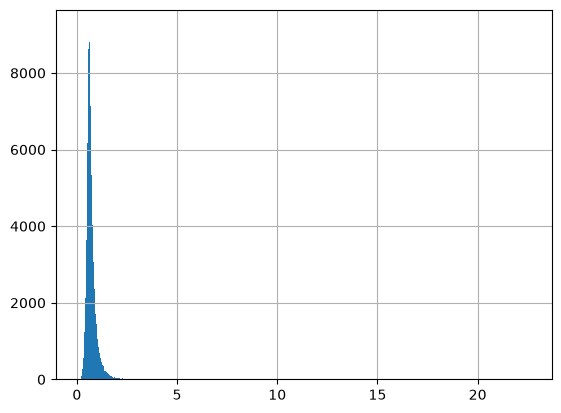

In [15]:
(df['I3']).hist(bins=10000)

<Axes: >

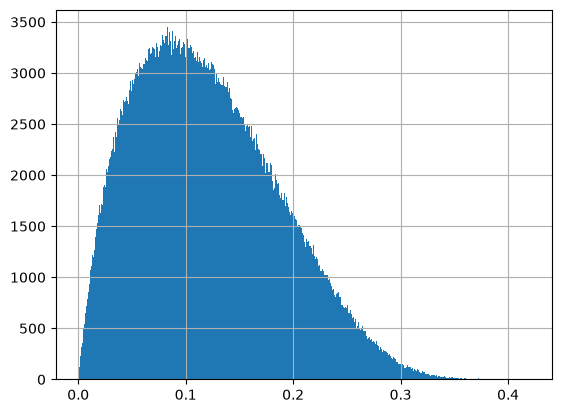

In [16]:
(df['I1']*df['I2']).hist(bins=1000)

In [17]:
df['I12'] = df['I1'] * df['I2']

In [18]:
df[['I12','OR2', 'OR3', 'OR4']].corr()

,I12,OR2,OR3,OR4
I12,1.000000,-0.000548,-0.000405,-0.000744
OR2,-0.000548,1.000000,-0.295505,-0.107100
OR3,-0.000405,-0.295505,1.000000,-0.019635
OR4,-0.000744,-0.107100,-0.019635,1.000000


In [19]:
dfmin = df[['I1', 'I2', 'I3', 'I4']]
corr = dfmin.corr(method="spearman", numeric_only=True)
corr

,I1,I2,I3,I4
I1,1.000000,0.156712,-0.500062,-0.746171
I2,0.156712,1.000000,0.062978,-0.579379
I3,-0.500062,0.062978,1.000000,0.047506
I4,-0.746171,-0.579379,0.047506,1.000000


In [20]:
df["I3-I1"] = df["I3"] - df["I1"]

## 3rd minima estimates

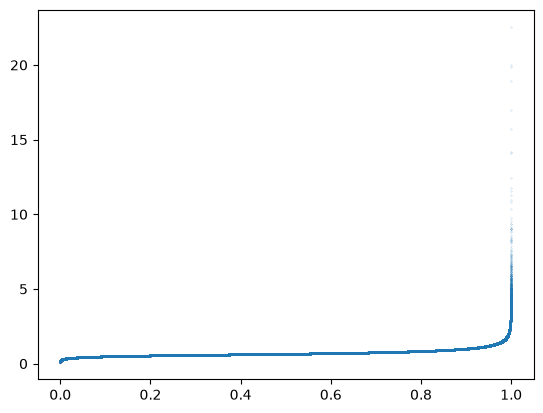

In [323]:
d = (df["I3"]).to_numpy() 

n = len(d)
x = np.sort(d)
plt.scatter(np.arange(n)/n, x, s = 0.01)

# x values from 0 to max(d)
x_vals = np.linspace(0, d.max(), 500)

# y = number of samples bigger than x
counts = np.array([(d > x).sum() for x in x_vals]) / n

# optional: fit only the tail, e.g. fit_quantile=0.7
threshold = np.quantile(d, 1 - 0.99)





In [335]:

# x values from 0 to max(d)
lin_span = 10000
x_vals = np.linspace(0, d.max(), lin_span)

# y = number of samples bigger than x
counts = np.array([(d > x).sum() for x in x_vals]) / n

# optional: fit only the tail, e.g. fit_quantile=0.7
threshold = np.quantile(d, 1 - 0.5)

mask = (x_vals > 0) & (counts > 0) & (x_vals >= threshold) #& (x_vals < 20)


In [336]:
idx = 1
for i in range(len(counts)-2, 1, -1):
    if counts[i] != idx/n:
        print(f'non {idx} found at {i}, {100 * i/len(counts):.2f}%, d[{i}]={counts[i]}')
        idx += 1
    if idx > 9:
        break

non 1 found at 8854, 88.54%, d[8854]=1.4392630972941853e-06
non 2 found at 8804, 88.04%, d[8804]=2.1588946459412782e-06
non 3 found at 8392, 83.92%, d[8392]=2.8785261945883707e-06
non 4 found at 7519, 75.19%, d[7519]=3.5981577432354636e-06
non 5 found at 6954, 69.54%, d[6954]=4.3177892918825564e-06
non 6 found at 6267, 62.67%, d[6267]=5.0374208405296485e-06
non 7 found at 6257, 62.57%, d[6257]=5.757052389176741e-06
non 8 found at 5498, 54.98%, d[5498]=6.476683937823834e-06
non 9 found at 5216, 52.16%, d[5216]=7.196315486470927e-06


0.5462428670506676 10.388692570998094
Considering only 4361/10000 values


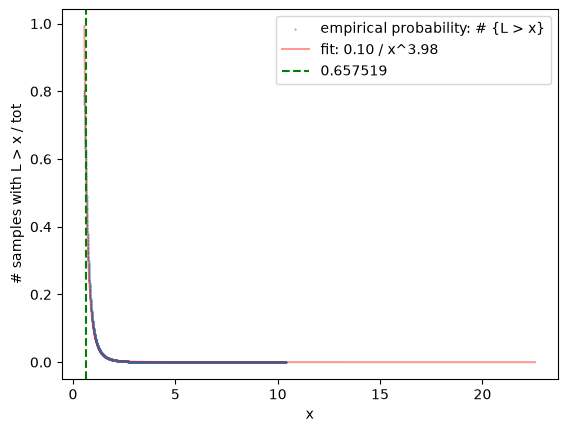

In [348]:
# optional: fit only the tail, e.g. fit_quantile=0.7

threshold_low = np.quantile(d, 0.2)
threshold_up = np.quantile(d, 1 - 0.00001)
print(threshold_low, threshold_up)
mask = (x_vals > 0) & (counts > 0) & (x_vals >= threshold_low) & (x_vals <= threshold_up)

print(f'Considering only {sum(mask)}/{len(mask)} values')
log_x = np.log(x_vals[mask])
log_y = np.log(counts[mask])

slope, intercept = np.polyfit(log_x, log_y, 1)

a_hat = -slope
C_hat = np.exp(intercept)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = C_hat * x_vals[mask_pos] ** (-a_hat)

mask_plot = mask_pos & (fit_y < 1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L > x}",
            s=0.1)

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {C_hat:.2f} / x^{a_hat:.2f}",
         color="red", alpha = 0.4)

plt.xlabel("x")
plt.ylabel("# samples with L > x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}')

plt.legend()
plt.show()

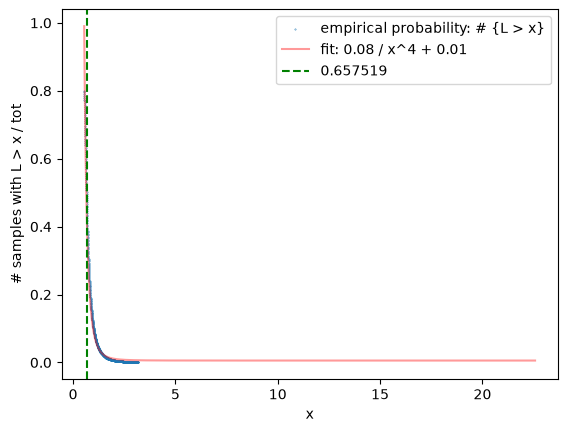

In [339]:
a = 4
xv = x_vals[mask] ** -a
lyv = counts[mask]

slope, intercept = np.polyfit(xv, lyv, 1)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = slope * x_vals[mask_pos] ** (-a) + intercept

mask_plot = mask_pos & (fit_y < 1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L > x}",
            s=0.1)

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {slope:.2f} / x^{a} + {intercept:.2f}",
         color="red", alpha = 0.4)

plt.xlabel("x")
plt.ylabel("# samples with L > x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}')

plt.legend()
plt.show()

In [84]:
from scipy.stats import norm
import math

d = np.sort(df["I3"].dropna().to_numpy())
n = len(d)

alpha0 = 4

rows = []
perc_span = np.linspace(0.0002, 0.005, 100)

for perc in perc_span:
    k = math.ceil(perc*n)
    u = d[-k-1]
    tail = d[-k:]
    gamma_hat = np.mean(np.log(tail / u))
    alpha_hat = 1 / gamma_hat
    
    se = alpha_hat / math.sqrt(k)
    
    # Test H0: alpha = 4 using the Hill asymptotic normal approximation
    se0 = alpha0 / math.sqrt(k)
    z = (alpha_hat - alpha0) / se0
    p_value = 2 * (1 - norm.cdf(abs(z)))
    
    rows.append({
        "k": k,
        "perc": perc,
        "threshold": u,
        "alpha_hat": alpha_hat,
        "ci_low": alpha_hat - 1.96 * se,
        "ci_high": alpha_hat + 1.96 * se,
        "z_alpha_eq_alpha0": z,
        "p_value_alpha_eq_alpha0": p_value,
        "C_hat_alpha0": (k / n) * u**4,
    })

out = pd.DataFrame(rows)
out

,k,perc,threshold,alpha_hat,ci_low,ci_high,z_alpha_eq_alpha0,p_value_alpha_eq_alpha0,C_hat_alpha0
0,278,0.000200,4.712196,3.998697,3.528638,4.468756,-0.005432,0.995666,0.098639
1,346,0.000248,4.503107,4.135067,3.699354,4.570780,0.628099,0.529939,0.102385
2,413,0.000297,4.325210,4.175677,3.772953,4.578401,0.892545,0.372101,0.104013
3,481,0.000345,4.157778,4.127668,3.758786,4.496551,0.699996,0.483930,0.103443
4,548,0.000394,3.984480,3.955914,3.624697,4.287131,-0.258005,0.796403,0.099398
...,...,...,...,...,...,...,...,...,...
95,6679,0.004806,2.132430,3.972634,3.877359,4.067909,-0.559128,0.576074,0.099385
96,6746,0.004855,2.127753,3.977631,3.882711,4.072551,-0.459311,0.646011,0.099504
97,6814,0.004903,2.121288,3.969465,3.875214,4.063716,-0.630143,0.528601,0.099291
98,6881,0.004952,2.115596,3.965967,3.872258,4.059675,-0.705782,0.480324,0.099196


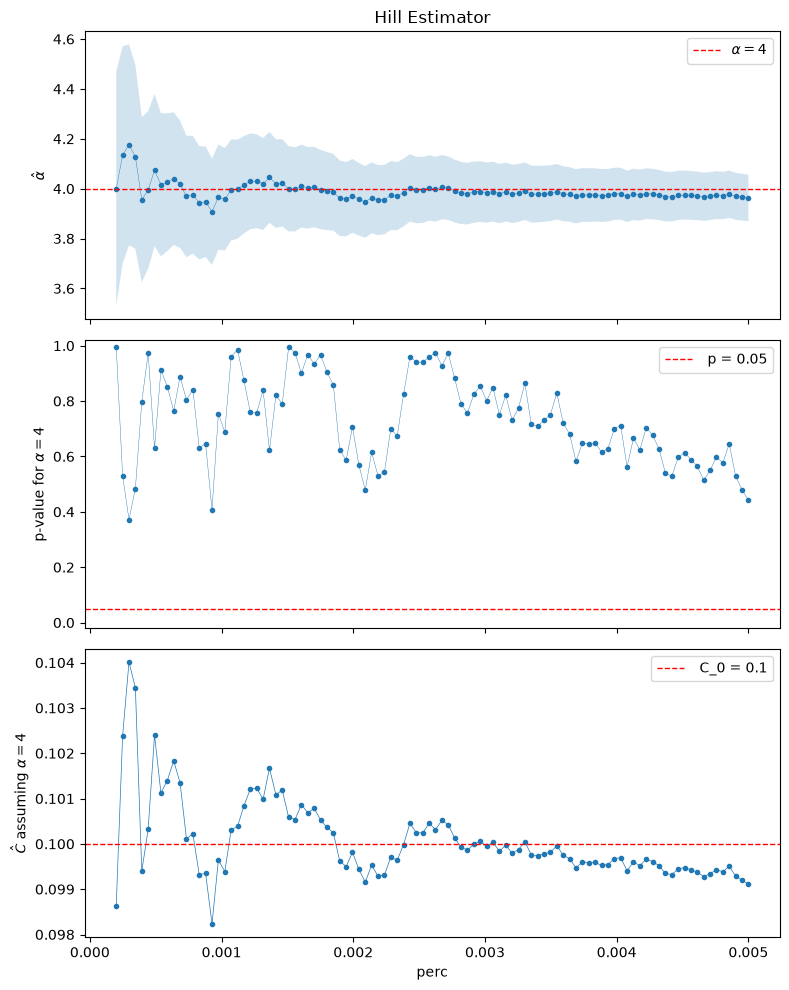

In [85]:
title = 'Hill Estimator'
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

ax = axes[0]
ax.plot(out["perc"], out["alpha_hat"], marker=".", linewidth=0.3)
ax.fill_between(out["perc"], out["ci_low"], out["ci_high"], alpha=0.2)
ax.axhline(alpha0, color="red", linestyle="--", linewidth=1, label=fr"$\alpha={alpha0}$")
ax.set_ylabel(r"$\hat\alpha$")
ax.set_title(title or "Hill tail diagnostics")
ax.legend()

ax = axes[1]
ax.plot(out["perc"], out["p_value_alpha_eq_alpha0"], marker=".", linewidth=0.3)
p = 0.05
ax.axhline(p, color="red", linestyle="--", linewidth=1, label=f"{ p = }")
ax.set_ylabel(fr"p-value for $\alpha={alpha0}$")
ax.set_ylim(-0.02, 1.02)
ax.legend()

ax = axes[2]
ax.plot(out["perc"], out["C_hat_alpha0"], marker=".", linewidth=0.5)
C_0 = 0.1
ax.axhline(C_0, color="red", linestyle="--", linewidth=1, label=f"{ C_0 = }")
ax.set_ylabel(fr"$\hat C$ assuming $\alpha={alpha0}$")
ax.set_xlabel("perc")
ax.legend()

plt.tight_layout()
plt.show()


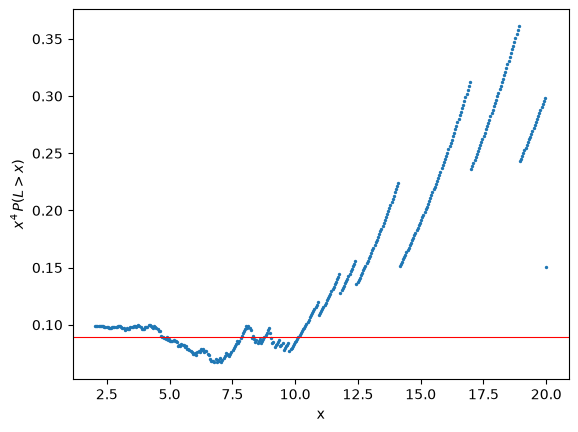

In [294]:
mask = (x_vals > 0) & (counts > 0) & (x_vals >= 2) & (x_vals < 20)

scaled = counts[mask] * x_vals[mask]**4

plt.scatter(x_vals[mask], scaled, s=2)
plt.axhline(slope, color="red", linewidth=0.8)
plt.xlabel("x")
plt.ylabel(r"$x^4\,P(L>x)$")
plt.show()

## 1st and 2nd minima product estimate

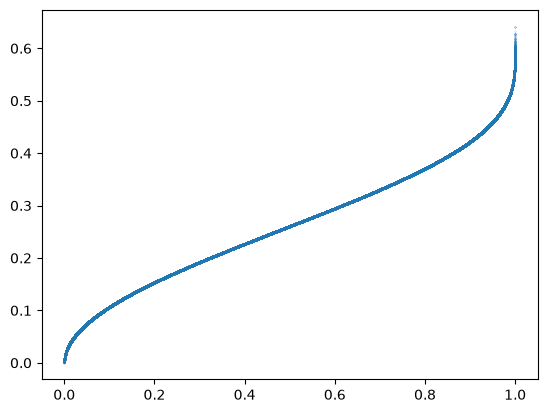

In [351]:
# d = (df["I1"]*df["I2"]).to_numpy() 
d = (df["I1"]).to_numpy() 
n = len(d)
x = np.sort(d)
plt.scatter(np.arange(n)/n, x, s = 0.01)

In [356]:
# x values from 0 to max(d)
x_vals = np.linspace(0, d.max(), 10000)

# y = number of samples bigger than x
counts = np.array([(d < x).sum() for x in x_vals]) / n

# optional: only consider vectors shorter than c * p 
# seems, that c = 0.01 start to give results
threshold = 0.3

# the reason for this sieve is that we expect that for shorter vectors the heuristic will better hold
# and we only care about the short case, corresponding to the long tail for lambda_3
mask = (x_vals > 0) & (counts > 0) & (x_vals <= threshold)

# TODO: understand the number theory behind this

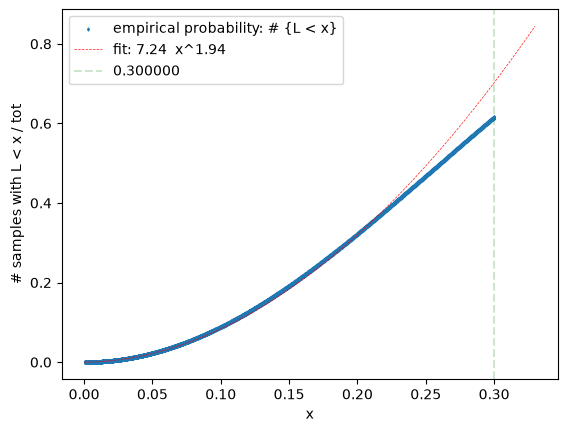

Considering 5143 points


In [358]:

log_x = np.log(x_vals[mask])
log_y = np.log(counts[mask])

slope, intercept = np.polyfit(log_x, log_y, 1)

a_hat = slope
C_hat = np.exp(intercept)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = C_hat * x_vals[mask_pos] ** (a_hat)

mask_plot = mask_pos & (fit_y < 1) & (x_vals <= threshold*1.1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L < x}",
            s=2, marker = 'd')

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {C_hat:.2f}  x^{a_hat:.2f}",
         color="red", alpha=0.9, linestyle="--", linewidth=0.5)

plt.xlabel("x")
plt.ylabel("# samples with L < x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}', alpha=0.2)

plt.legend()
plt.show()

print(f'Considering {sum([ 1 for m in mask_plot if m])} points')

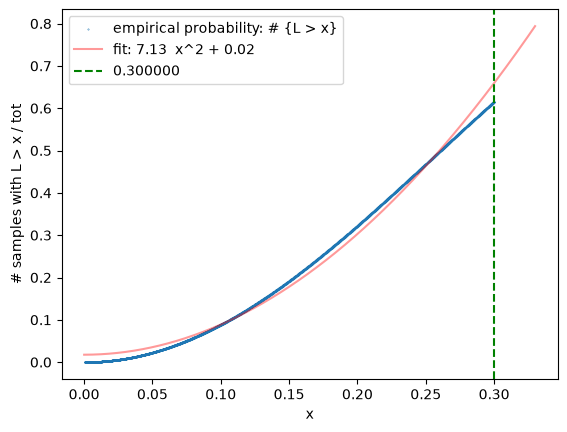

In [359]:
a = 2
xv = x_vals[mask] ** a
lyv = counts[mask]

slope, intercept = np.polyfit(xv, lyv, 1)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = slope * x_vals[mask_pos] ** (a) + intercept

mask_plot = mask_pos & (fit_y < 1) & (x_vals <= threshold*1.1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L > x}",
            s=0.1)

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {slope:.2f}  x^{a} + {intercept:.2f}",
         color="red", alpha = 0.4)

plt.xlabel("x")
plt.ylabel("# samples with L > x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}')

plt.legend()
plt.show()

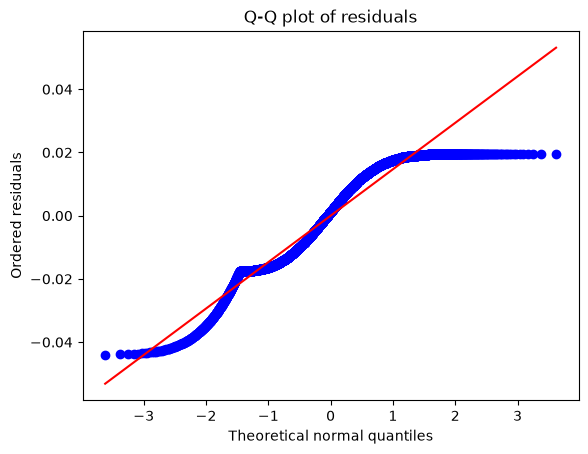

In [360]:
fitted = fit_y[mask]
residuals = counts[mask] - fitted

# Q-Q plot against a normal distribution
stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q plot of residuals")
plt.xlabel("Theoretical normal quantiles")
plt.ylabel("Ordered residuals")
plt.show()

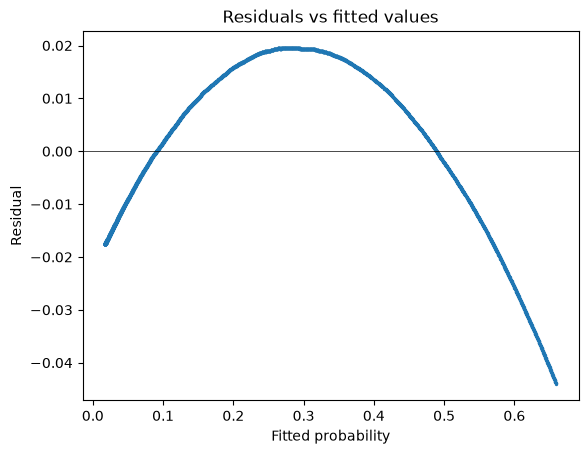

In [361]:
plt.scatter(fitted, residuals, s=2)
plt.axhline(0, color="black", linewidth=0.5)

plt.xlabel("Fitted probability")
plt.ylabel("Residual")
plt.title("Residuals vs fitted values")
plt.show()

In [32]:
df.describe()

,I1,I2,I3,I4,OL2,OL3,OL4,OR2,OR3,OR4,...,inner32,inner33,inner34,inner41,inner42,inner43,inner44,n_nonzero_inner,I12,I3-I1
count,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,...,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06,1.061732e+06
mean,2.630352e-01,4.557375e-01,7.192297e-01,1.513654e+00,1.866898e-01,4.891014e-01,1.926442e+00,1.963678e-01,4.654981e-01,1.677146e+00,...,5.334086e-01,5.339775e-01,5.344644e-01,5.336008e-01,5.336196e-01,5.344644e-01,5.334237e-01,3.199685e+00,1.209188e-01,4.561945e-01
std,1.173876e-01,1.434454e-01,2.866589e-01,2.410889e+00,1.190433e-01,2.239696e-01,3.525464e+00,1.025966e-01,2.918060e-01,1.354911e+01,...,4.988829e-01,4.988444e-01,4.988110e-01,4.988699e-01,4.988687e-01,4.988110e-01,4.988818e-01,1.037828e+00,6.643038e-02,3.587989e-01
min,4.519293e-04,1.246218e-02,7.060043e-02,5.276863e-01,5.716485e-03,1.373676e-01,4.392945e-01,2.827923e-06,7.100945e-03,4.021314e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,7.918174e-05,1.977241e-04
25%,1.733317e-01,3.646159e-01,5.674607e-01,8.445860e-01,9.104309e-02,3.680676e-01,6.836207e-01,1.139538e-01,3.350984e-01,6.374190e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,6.858182e-02,2.202398e-01
50%,2.608858e-01,4.543905e-01,6.575271e-01,1.082428e+00,1.514222e-01,4.251591e-01,9.912592e-01,1.920459e-01,4.220681e-01,8.785435e-01,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,1.132420e-01,3.754241e-01
75%,3.498543e-01,5.359548e-01,7.937359e-01,1.558585e+00,2.633305e-01,5.601034e-01,1.536394e+00,2.747863e-01,5.185368e-01,1.434779e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,1.658693e-01,5.935203e-01
max,6.411129e-01,4.246353e+00,2.257154e+01,6.014403e+02,4.130801e-01,1.155270e+00,1.994207e+01,5.030774e-01,4.238355e+01,8.073683e+03,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00,4.154098e-01,2.256872e+01


In [33]:
df.iloc[:, :4].quantile([1-1/4**i for i in range(1,10)])

,I1,I2,I3,I4
0.750000,0.349854,0.535955,0.793736,1.558585
0.937500,0.448546,0.657370,1.129120,3.087267
0.984375,0.503579,0.815776,1.586744,6.105624
0.996094,0.538963,1.023006,2.241954,12.191112
0.999023,0.564212,1.287409,3.159043,24.009600
0.999756,0.585982,1.606317,4.467044,47.072947
0.999939,0.602525,2.007305,5.914805,92.210065
0.999985,0.617194,2.516006,8.594264,190.529117
0.999996,0.627122,2.931343,14.147143,406.117862


<Axes: >

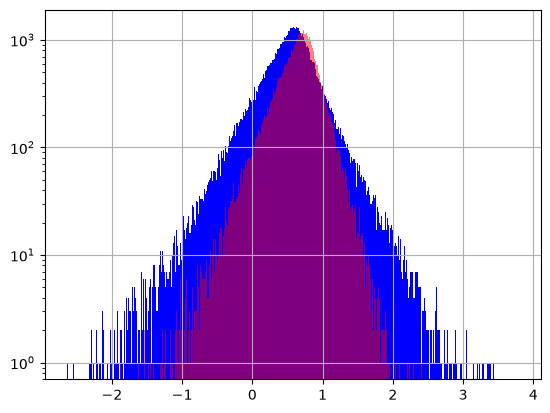

In [59]:
np.log(6*df['I4']*df['I1']).hist(bins=800, log=True, color='blue')
np.log(1.3/df['I3']).hist(bins=800, log=True, alpha=0.5, color='red')

np.float64(0.37213374468177024)

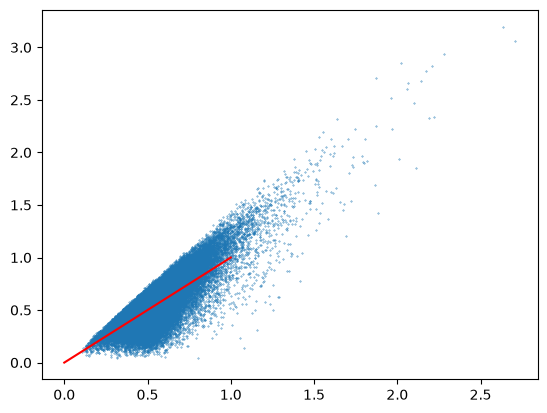

In [64]:
fun1 = np.sqrt(df['I1'] * df['I4'])
m = (fun1 * df['I3']).mean()
plt.scatter(fun1, m/(df['I3']), s=0.1)
plt.plot((0,1), (0,1), 'red')
m

np.float64(0.08967262331255478)

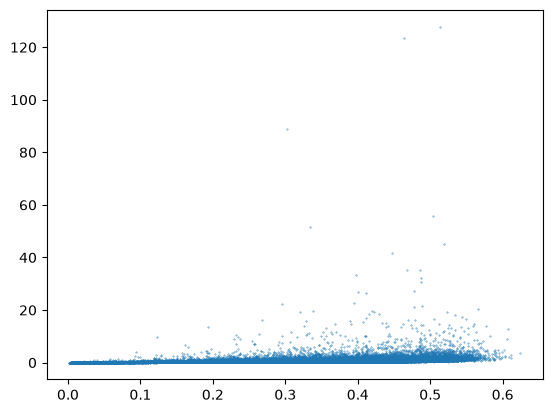

In [43]:
m = (df['I1'] * df['I3-I1']).mean()
plt.scatter(df['I1'], m/df['I3-I1'], s=0.1)
#plt.plot((0,1), (0,1), 'red')
m

np.float64(0.3134985534315788)

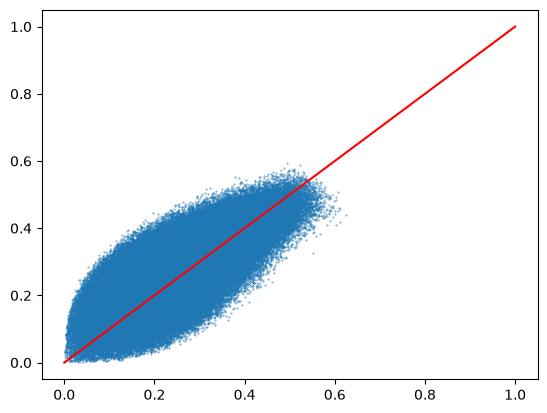

In [24]:
m = (df['I1'] * df['I4']).mean()
plt.scatter(df['I1'], m/df['I4'], s=0.1)
plt.plot((0,1), (0,1), 'red')
m

In [160]:
p = 62

# Use the newest merged file for this p.
files = sorted(Path('.').glob(f'data/{p}-eichler-*.csv'))
if not files:
    raise FileNotFoundError(f'No merged CSV found for p={p}')
data_file = files[-1]
data_file

PosixPath('data/62-eichler-20260708-163832.csv')

# Data with Eichler order minima

In [336]:
columns = (
    ['I1', 'I2', 'I3', 'I4']
    + ['O2', 'O3', 'O4'])

dfe = pd.read_csv(data_file, comment='#', header=None, names=columns)
dfe

,,,,,,,,,,,,,,,,,,,I1,I2,I3,I4,O2,O3,O4
0.199057,0.373286,1.125247,1.166691,0.041085,1.155270,1.432343,0.153889,0.627164,0.680539,1,0,0,0,0,0,1,1,0,1,1,1,0,1,1,0
0.357934,0.502966,0.558076,1.063522,0.263841,0.273651,0.882299,0.230327,0.426679,0.640375,1,1,1,0,1,0,0,1,1,0,1,1,0,1,1,0
0.215919,0.410024,0.603909,1.335379,0.382591,0.438924,0.549756,0.264093,0.399542,0.667413,1,1,1,0,1,0,0,0,1,0,0,1,0,0,1,0
0.186652,0.299044,1.033956,1.202712,0.228714,0.357403,0.812369,0.030545,0.301301,6.885653,0,1,0,1,1,0,0,1,0,0,1,1,1,1,1,0
0.548765,0.557894,0.654248,0.680699,0.280264,0.462858,0.602370,0.173849,0.440133,0.902464,0,1,0,1,1,1,0,1,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.281463,0.297319,0.916826,1.005816,0.160268,0.587597,0.723861,0.178580,0.449866,0.824249,0,1,1,1,1,1,0,0,1,0,0,0,1,0,0,1
0.496825,0.547623,0.612859,0.643620,0.127664,0.226689,2.248476,0.113947,0.256110,2.236113,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0
0.313496,0.333596,0.653846,0.976881,0.153324,0.508496,0.813367,0.178353,0.348721,1.048258,0,0,1,1,0,0,1,0,1,1,0,1,1,0,1,1
0.196949,0.523499,0.567019,1.276337,0.214538,0.221671,1.405477,0.268115,0.347810,0.732079,1,0,1,0,0,1,1,1,1,1,0,0,0,1,0,1


In [337]:
dfe.corr()

,I1,I2,I3,I4,O2,O3,O4
I1,1.000000,-0.074513,-0.071945,0.023083,-0.074239,-0.071945,0.003847
I2,-0.074513,1.000000,-0.071092,0.007892,0.001026,-0.071092,-0.071691
I3,-0.071945,-0.071092,1.000000,-0.072609,-0.067570,1.000000,-0.066945
I4,0.023083,0.007892,-0.072609,1.000000,-0.070938,-0.072609,-0.072991
O2,-0.074239,0.001026,-0.067570,-0.070938,1.000000,-0.067570,-0.072114
O3,-0.071945,-0.071092,1.000000,-0.072609,-0.067570,1.000000,-0.066945
O4,0.003847,-0.071691,-0.066945,-0.072991,-0.072114,-0.066945,1.000000


In [338]:
dfe['I12'] = dfe['I1'] * dfe['I2']

np.float64(0.1313957008779897)

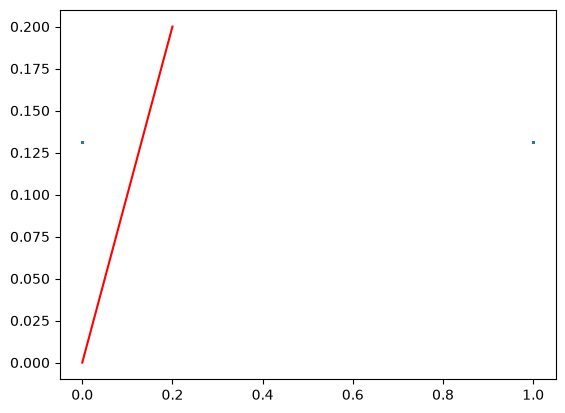

In [339]:
m = (dfe['I12'] * dfe['O2']).mean()
plt.scatter(dfe['I12'], m/dfe['O2'], s=0.1)
plt.plot((0,0.2), (0,0.2), 'red')
m

np.float64(0.08426160801119466)

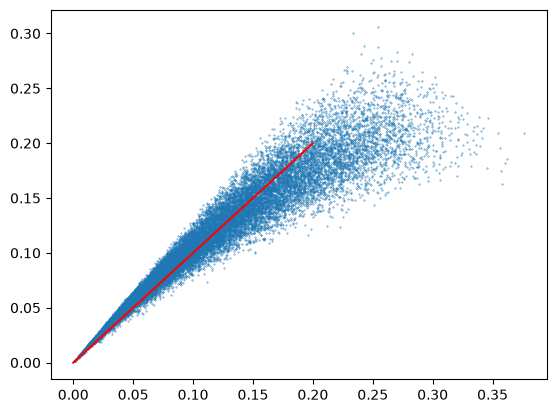

In [179]:
m = (dfe['I12'] * dfe['I3']*dfe['I4']).mean()
plt.scatter(dfe['I12'], m/ (dfe['I3']*dfe['I4']), s=0.1)
plt.plot((0,0.2), (0,0.2), 'red')
m